In [2]:
import random
from ortools.sat.python import cp_model
from matplotlib import pyplot as plt

In [4]:
params = {
        "tps": 8,
        "final_product": "JT12",
        "amount": 2,
        "horizon": 100,
    }
boms = {
    "JT4": {
        "JT1": 2,
        "JT2": 1,
    },
    "JT5": {
        "JT1": 1,
    },
    "JT9": {
        "JT4": 1,
        "JT5": 1,
    },
    "JT12": {
        "JT9": 1,
        "JT5": 1,
    },
}

factories = {
    # 원재료 생산
    "Fc1": {
        "JT1": {"lots": [5, 10], "time": 1},
        "JT2": {"lots": [5, 10], "time": 1},
    },

    # 1차 가공
    "Fc2": {
        "JT4": {"lots": [2], "time": 2},
        "JT5": {"lots": [2], "time": 2},
    },

    # 2차 가공
    "Fc3": {
        "JT9": {"lots": [1], "time": 3},
    },

    # 최종 제품
    "Fc4": {"JT12": {"lots": [1], "time": 4}}}
fcs = list(factories)
random.seed(4233)
deliveries = {fc1: {fc2 : random.randint(3, 8) if fc1 != fc2 else 1 for fc2 in fcs} for fc1 in fcs}

In [5]:
class Process:
    def __init__(self): pass

In [6]:
class Deliver:
    def __init__(self): pass

In [7]:
process, deliver, ini_set = Process(), Deliver(), {}
for fc in factories.keys():
    ini_set[fc] = {}
    for jt in factories[fc].keys():
        ini_set[fc][jt] = factories[fc][jt]["lots"]
        setattr(process, f"{fc}{jt}", factories[fc][jt]["time"])
for fc1 in deliveries.keys():
    for fc2 in deliveries[fc1].keys():
        setattr(deliver, f"{fc1}{fc2}", deliveries[fc1][fc2])

In [8]:
horizon = params["horizon"]
job_interval_horizon = params["horizon"]

In [31]:
md = cp_model.CpModel()

fc_wip_t, ingredients = {}, {}
for fc in ini_set.keys():
    fc_wip_t[fc] = {}
    for jt in ini_set[fc].keys():
        fc_wip_t[fc][jt] = {}
        if jt in boms:
            for ingredient in boms[jt]:
                if ingredient not in fc_wip_t[fc]: fc_wip_t[fc][ingredient] = {}
                if fc not in ingredients: ingredients[fc] = set()
                ingredients[fc].add(ingredient)

    for wip in fc_wip_t[fc].keys():
        fc_wip_t[fc][wip][0] = 0
        for t in range(1, horizon):
            fc_wip_t[fc][wip][t] = md.new_int_var(0, horizon, f"{fc}_{wip}_{t}")

delivered = {}
for fc in ini_set.keys():
    delivered[fc] = {}
    for jt in ini_set[fc].keys():
        if jt in boms:
            for ingredient in boms[jt]:
                make_ingredient_fc = [fc_prime for fc_prime in ini_set.keys() if ingredient in ini_set[fc_prime]]
                delivered[fc][ingredient] = {fc_prime: {t: md.new_int_var(0, horizon, f"{fc}_{ingredient}_{t}_delivered") for t in range(1, horizon)} for fc_prime in make_ingredient_fc}


sem, intervals = {}, {} # Start End Make => Interval
produced, consumed = {}, {}
se_event = {}
for fc in ini_set.keys():
    sem[fc] = {}
    intervals[fc] = {}
    produced[fc] = {}
    consumed[fc] = {}
    se_event[fc] = {}
    for jt in ini_set[fc].keys():
        sem[fc][jt] = {}
        intervals[fc][jt] = {}
        produced[fc][jt] = {t: md.new_bool_var(f"{fc}_{jt}_{t}_produced") for t in range(1, horizon)}
        if jt in boms:
            consumed[fc][jt] = {ingredient: {t: md.new_int_var(0, boms[jt][ingredient], f"{fc}_{ingredient}_{t}_consumed") for t in range(1, horizon)} for ingredient in boms[jt].keys()}

        se_event[fc][jt] = {}
        for k in range(job_interval_horizon):
            se_event[fc][jt][k] = {}
            sem[fc][jt][k] = [md.new_int_var(1, horizon - 1, f"{fc}_{jt}_{k}_st"), md.new_int_var(1, horizon - 1, f"{fc}_{jt}_{k}_ed"), md.new_bool_var(f"{fc}_{jt}_{k}_mk")]
            intervals[fc][jt][k] = md.new_optional_interval_var(sem[fc][jt][k][0], getattr(process, f"{fc}{jt}"), sem[fc][jt][k][1], sem[fc][jt][k][2], f"{fc}_{jt}_{k}_make")

            if k:
                md.add(sem[fc][jt][k - 1][2] >= sem[fc][jt][k][2])
                md.add(sem[fc][jt][k - 1][1] <= sem[fc][jt][k][0])

            for t in range(1, horizon):
                se_event[fc][jt][k][t] = [md.new_bool_var(f"{fc}{jt}{k}_{when}_{t}") for when in ("start", "end","real_start","real_end")]
                md.add(sem[fc][jt][k][0] == t).only_enforce_if(se_event[fc][jt][k][t][0])
                md.add(sem[fc][jt][k][0] != t).only_enforce_if(se_event[fc][jt][k][t][0].Not())

                md.add(sem[fc][jt][k][1] == t).only_enforce_if(se_event[fc][jt][k][t][1])
                md.add(sem[fc][jt][k][1] != t).only_enforce_if(se_event[fc][jt][k][t][1].Not())

                md.add_min_equality(se_event[fc][jt][k][t][2], [se_event[fc][jt][k][t][0], sem[fc][jt][k][2]])
                md.add_min_equality(se_event[fc][jt][k][t][3], [se_event[fc][jt][k][t][1], sem[fc][jt][k][2]])

        md.add_no_overlap(intervals[fc][jt].values())

        if jt in boms:
            for ingredient in boms[jt].keys():
                for t in range(1, horizon):
                    md.add(consumed[fc][jt][ingredient][t] == boms[jt][ingredient] * sum(se_event[fc][jt][k][t][2] for k in range(job_interval_horizon)))

        for t in range(1, horizon):
            md.add(produced[fc][jt][t] == 1 * sum(se_event[fc][jt][k][t][3] for k in range(job_interval_horizon)))

    if fc in ingredients:
        for ingredient in ingredients[fc]:
            use_this_ingredient_jt = [jt for jt in ini_set[fc].keys() if jt in boms and ingredient in boms[jt]]
            for t in range(1, horizon):
                md.add(fc_wip_t[fc][ingredient][t - 1] + sum(delivered[fc][ingredient][fc_prime][t] for fc_prime in ini_set.keys() if ingredient in ini_set[fc_prime]) >= sum(boms[jt][ingredient] * sum(se_event[fc][jt][k][t][2] for k in range(job_interval_horizon)) for jt in use_this_ingredient_jt))

delivering = {}
for fc in ini_set.keys():
    delivering[fc] = {}
    for jt in ini_set[fc].keys():
        delivering[fc][jt] = {}
        use_ingredient_fc, lot_units = set([fc_prime for fc_prime in ini_set.keys() for jt_prime in ini_set[fc_prime] if jt_prime in boms and jt in boms[jt_prime]]), ini_set[fc][jt]
        for t in range(1, horizon):
            delivering[fc][jt][t] = {}
            for fc_prime in use_ingredient_fc:
                delivering[fc][jt][t][fc_prime] = {}
                for lot_unit in lot_units:
                    delivering[fc][jt][t][fc_prime][lot_unit] = md.new_int_var(0, horizon // 10, f"{fc}_{jt}_{t}_deliver_to_{fc_prime}_{lot_unit}")
            md.add(fc_wip_t[fc][jt][t - 1] + produced[fc][jt][t] - sum(consumed[fc][jt_prime][jt][t] for jt_prime in ini_set[fc].keys() if jt_prime in boms and jt in boms[jt_prime])>= sum(delivering[fc][jt][t][fc_prime][lot_unit] * lot_unit for fc_prime in use_ingredient_fc for lot_unit in lot_units))

        for fc_prime in use_ingredient_fc:
            deliver_time = getattr(deliver, f"{fc}{fc_prime}")
            for t in range(1, horizon):
                if t + deliver_time < horizon:
                    md.add(sum(delivering[fc][jt][t][fc_prime][lot_unit] * lot_unit for lot_unit in lot_units) == delivered[fc_prime][jt][fc][t + deliver_time])
                else:
                    md.add(sum(delivering[fc][jt][t][fc_prime][lot_unit] * lot_unit for lot_unit in lot_units) == 0)
            for t in range(1, min(horizon, deliver_time + 1)):
                md.add(delivered[fc_prime][jt][fc][t] == 0)

plus, minus = {}, {}
for fc in fc_wip_t.keys():
    plus[fc] = {}
    minus[fc] = {}

    for wip in fc_wip_t[fc].keys():
        plus[fc][wip] = {}
        minus[fc][wip] = {}

        for t in range(1, horizon):
            plus[fc][wip][t] = md.new_int_var(0, horizon // 10, f"{fc}_{wip}_{t}_plus")
            minus[fc][wip][t] = md.new_int_var(0, horizon // 10, f"{fc}_{wip}_{t}_minus")

            md.add(plus[fc][wip][t] == (produced[fc][wip][t] if wip in produced[fc] else 0) + (sum(delivered[fc][wip][fc_prime][t] for fc_prime in delivered[fc][wip]) if wip in delivered[fc] else 0))
            md.add(minus[fc][wip][t] == sum(consumed[fc][jt_prime][wip][t] for jt_prime in consumed[fc] if wip in consumed[fc][jt_prime]) + (sum(delivering[fc][wip][t][fc_prime][lot_unit] * lot_unit for fc_prime in delivering[fc][wip][t].keys() for lot_unit in delivering[fc][wip][t][fc_prime].keys()) if wip in delivering[fc] and t in delivering[fc][wip] else 0))
            md.add(fc_wip_t[fc][wip][t] == fc_wip_t[fc][wip][t - 1] + plus[fc][wip][t] - minus[fc][wip][t])

every_final_product_max_set = {}
for fc in ini_set.keys():
    if params["final_product"] in ini_set[fc]:
        every_final_product_max_set[fc] = md.new_int_var(0, params["amount"], f"{fc}_FP")
        md.add_max_equality(every_final_product_max_set[fc], fc_wip_t[fc][params["final_product"]].values())
md.add(sum(every_final_product_max_set.values()) >= params["amount"])

every_fc_num_job = {}
for fc in ini_set.keys():
    every_fc_num_job[fc] = md.new_int_var(0, job_interval_horizon * len(ini_set[fc]), f"{fc}_total_job_num")
    md.add(every_fc_num_job[fc] == sum(sem[fc][jt][k][2] for k in range(job_interval_horizon) for jt in ini_set[fc]))

total_makespan = md.new_int_var(0, horizon, "total_makespan")
md.add_max_equality(total_makespan, [sem[fc][jt][k][1] for fc in sem.keys() for jt in sem[fc].keys() for k in range(job_interval_horizon)])

md.minimize(9999 * total_makespan + sum(every_fc_num_job.values()))
solver = cp_model.CpSolver()
status = solver.Solve(md)

In [ ]:
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    total_makespan = round(solver.Value(total_makespan))
    print("Total Makespan :", total_makespan, "\n")

    for t in range(1, total_makespan + 1):
        print(f"========== time : {t} ==========\n")
        for fc in ini_set.keys():
            print(f"--{fc}--\n")

            print("Making_info\n")
            for jt in ini_set[fc].keys():
                print(jt)
                if jt in boms:
                    already_has, now_delivered = {}, {}
                    for ingredient in boms[jt]:
                        already_has[ingredient] = solver.Value(fc_wip_t[fc][ingredient][t-1])
                        now_delivered[ingredient] = sum(solver.Value(delivered[fc][ingredient][fc_prime][t]) for fc_prime in ini_set.keys() if ingredient in ini_set[fc_prime])
                    total_ingredients = {ingredient: round(already_has[ingredient] + now_delivered[ingredient]) for ingredient in boms[jt].keys()}

                    decision_making_making = []
                    for ingredient in boms[jt].keys():
                        decision_making_making.append(total_ingredients[ingredient] >= boms[jt][ingredient])
                    print(f"{already_has} + {now_delivered} == {total_ingredients}     vs     {boms[jt]}")

                    if all(decision_making_making):
                        print("Able to Make")

                        do_not_make = False
                        for k in range(job_interval_horizon):
                            if round(solver.Value(se_event[fc][jt][k][t][2])):
                                print(f"Start to Make!!   //   From {round(solver.Value(sem[fc][jt][k][0]))} to {round(solver.Value(sem[fc][jt][k][1]))}")
                                break
                            if k == len(decision_making_making) - 1:
                                do_not_make = True
                        if do_not_make:
                            print("But do not make")
                    else:
                        print("Making Pass because of lack of ingredients")
                else:
                    print("Able to make without ingredients")
                    do_not_make = False
                    for k in range(job_interval_horizon):
                        st, ed = [round(solver.Value(sem[fc][jt][k][idx])) for idx in range(2)]
                        if round(solver.Value(se_event[fc][jt][k][t][2])):
                            print(f"Start to Make!!   {k}_th make From {st} to {ed}")
                            break
                        elif round(solver.Value(sem[fc][jt][k][2])) and st < t < ed:
                            print(f"Already Making!!  {k}_th make From {st} to {ed}")
                            break

                print()
                print("Going to Deliver")

                print()
            print()
        print("Work in Processes per t\n")
        for fc in fc_wip_t.keys():
            print(f"{fc}")
            for wip in fc_wip_t[fc].keys():
                print(f"\t{wip} : {round(solver.Value(fc_wip_t[fc][wip][t]))}")
        print()
else:
    print("X")

In [32]:
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    total_makespan = round(solver.Value(total_makespan))
    print("Total Makespan :", total_makespan, "\n")

Total Makespan : 40 



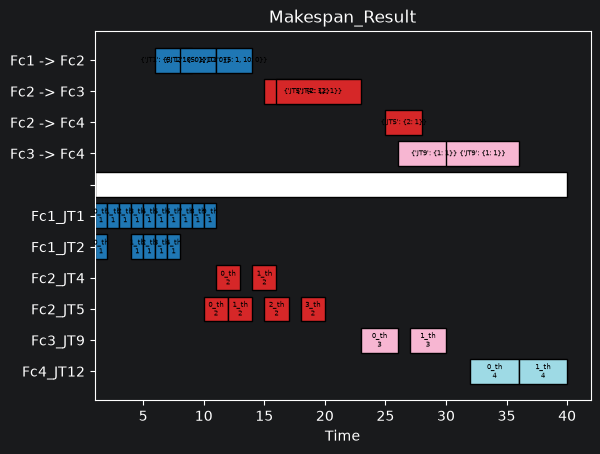

In [52]:
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):

    _, ax = plt.subplots()
    s_fc = list(ini_set)

    for fc in reversed(list(ini_set)):
        for jt in reversed(list(ini_set[fc])):
            ax.barh(f"{fc}_{jt}", 0, left=1)
    ax.barh(" ", total_makespan - 1, left=1, color='white', edgecolor='black')

    fc_deliver_to = {}
    for fc1 in reversed(list(ini_set)):
        for fc2 in reversed(list(ini_set)):
            for jt in ini_set[fc1]:
                if fc2 in set([fc_prime for fc_prime in ini_set.keys() for jt_prime in ini_set[fc_prime] if jt_prime in boms and jt in boms[jt_prime]]):
                    if fc1 not in fc_deliver_to: fc_deliver_to[fc1] = {}
                    if fc2 not in fc_deliver_to[fc1]:
                        fc_deliver_to[fc1][fc2] = []
                        ax.barh(f"{fc1} -> {fc2}", 0, left=1)
                    fc_deliver_to[fc1][fc2].append(jt)

    for fc in ini_set.keys():
        for jt in ini_set[fc].keys():
            for k in range(job_interval_horizon):
                st, ed, mk = [round(solver.Value(info)) for info in sem[fc][jt][k]]
                if mk:
                    ax.barh(f"{fc}_{jt}", ed - st, left=st, color=plt.get_cmap('tab20', len(s_fc))(s_fc.index(fc)), edgecolor='black')
                    ax.text((st + ed) / 2, f"{fc}_{jt}", f"{k}_th\n{ed - st}", va='center', ha='center', color='black', fontsize=5)

    for fc1 in fc_deliver_to.keys():
        for fc2 in fc_deliver_to[fc1].keys():
            for t in range(1, horizon):
                deliver_list = {}
                for jt in fc_deliver_to[fc1][fc2]:
                    if sum(solver.value(delivering[fc1][jt][t][fc2][lot_unit]) for lot_unit in ini_set[fc1][jt]):
                        deliver_list[jt] = {lot_unit: solver.value(delivering[fc1][jt][t][fc2][lot_unit]) for lot_unit in ini_set[fc1][jt]}
                if len(deliver_list):
                    st = t
                    pass_lists = []
                    for jt in deliver_list:
                        pass_lists.append(solver.value(delivered[fc2][jt][fc1][t+getattr(deliver, f"{fc1}{fc2}")]) == sum(lot_unit * lot_num for lot_unit, lot_num in deliver_list[jt].items()))
                    if all(pass_lists):
                        ax.barh(f"{fc1} -> {fc2}", getattr(deliver, f"{fc1}{fc2}"), left=t, color=plt.get_cmap('tab20', len(s_fc))(s_fc.index(fc1)), edgecolor='black')
                        ax.text(t + getattr(deliver, f"{fc1}{fc2}") / 2, f"{fc1} -> {fc2}", f"{deliver_list}", va='center', ha='center', color='black', fontsize=5)
                    else:
                        print("SERIOUS_ERRORS"*10)
                    # delivered[fc][ingredient][fc_prime][t]

    # agv_load_list = {agv: sorted([(job, op) for job in se_load_agv[agv].keys() for op in se_load_agv[agv][job]],
    #                              key=lambda sche: se_load_agv[agv][sche[0]][sche[1]][0]) for agv in agv_info}
    # for agv in agv_info:
    #     print(agv, agv_load_list[agv])
    # for agv in se_load_agv.keys():
    #     for job in se_load_agv[agv].keys():
    #         for op in se_load_agv[agv][job].keys():
    #             st, ed, attr = se_load_agv[agv][job][op]
    #             loading = ed - st
    #
    #             if round(loading) != 0:
    #                 ax.barh(agv, loading, left=st, color='orange', edgecolor='black')
    #                 ax.text(st + loading / 2, agv,
    #                         attr + f"\n{job}\n{list(ini_set[job])[list(ini_set[job]).index(op) - 1] if list(ini_set[job]).index(op) else "LU"}->{op}" + f"\n({loading})" if agv !=
    #                                                                                                                                                                         agv_info[
    #                                                                                                                                                                             0] else f"Special\n{job}",
    #                         va='center', ha='center', fontsize=5)
    #
    # for agv in se_unload_agv.keys():
    #     for job in se_unload_agv[agv].keys():
    #         for op in se_unload_agv[agv][job]:
    #             st, ed, attr = se_unload_agv[agv][job][op]
    #             unloading = ed - st
    #
    #             if round(unloading) != 0:
    #                 ax.barh(agv, unloading, left=st, color='white', edgecolor='black')
    #                 ax.text(st + unloading / 2, agv, attr + f"\n({unloading})", va='center', ha='center',
    #                         fontsize=5)
    #
    # ax.set_xticks([i for i in range(int(obj) + 2)])
    # ax.tick_params(axis='x', labelsize=5)
    # ax.set_yticks(range(len(machines) + len(agv_info)))
    # ax.set_yticklabels(machines + agv_info)
    ax.set_xlabel("Time")
    ax.set_title("Makespan_Result")
    plt.show()